<a href="https://colab.research.google.com/github/vikobaldigi/DATA-71200-Advanced-Data-Analysis-Methods-Project/blob/main/KovacevicVi_Project3_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 3: Unsupervised Learning

**Student:** Vi Kovacevic  
**Course:** DATA 71200 - Advanced Data Analytics  
**Date:** December 2024

---

## Project Overview

This project applies unsupervised learning techniques to the NYC High School Performance Dataset from Project 1. The analysis includes:

**Part 1: PCA for Feature Selection**
- Determine components needed for 95% variance retention
- Evaluate impact on best model from Project 2 (Random Forest)

**Part 2: Clustering Analysis**
- Apply 3 clustering algorithms (k-Means, Hierarchical, DBSCAN)
- Compare performance with and without PCA
- Evaluate using ARI and Silhouette Coefficient

**Dataset:**
- 410 NYC high schools (328 training, 82 testing)
- 15 predictor features
- Target: Performance (3 classes: Low, Medium, High)

---

## Step 1: Setup and Load Data

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Evaluation metrics
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.metrics import silhouette_samples

# For comparing with supervised model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Set random seed
np.random.seed(42)

# Visualization settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [2]:
# Load data from GitHub
train_url = 'https://raw.githubusercontent.com/vikobaldigi/DATA-71200-Advanced-Data-Analysis-Methods-Project/6455c8a0a1020cd56b6e128d78740f092b3f5d28/data/schools_train.csv'
test_url = 'https://raw.githubusercontent.com/vikobaldigi/DATA-71200-Advanced-Data-Analysis-Methods-Project/6455c8a0a1020cd56b6e128d78740f092b3f5d28/data/schools_test.csv'

train_df = pd.read_csv(train_url)
test_df = pd.read_csv(test_url)

print(f"Training set: {train_df.shape}")
print(f"Test set: {test_df.shape}")
print(f"\nTarget distribution in training set:")
print(train_df['Performance'].value_counts())

Training set: (328, 20)
Test set: (82, 20)

Target distribution in training set:
Performance
Low       110
Medium    109
High      109
Name: count, dtype: int64


In [3]:
# Separate features and target
X_train = train_df.drop(['Performance', 'DBN', 'School_Name', 'Neighborhood', 'MeanScore'], axis=1)
y_train = train_df['Performance']

X_test = test_df.drop(['Performance', 'DBN', 'School_Name', 'Neighborhood', 'MeanScore'], axis=1)
y_test = test_df['Performance']

print(f"Features: {X_train.shape}")
print(f"\nFeature list:")
for i, col in enumerate(X_train.columns, 1):
    print(f"  {i}. {col}")

Features: (328, 15)

Feature list:
  1. Leadership_Count
  2. Teacher_Count
  3. Other_Staff_Count
  4. Total_Staff
  5. Male_Teacher_Percentage
  6. Female_Teacher_Percentage
  7. Student_Teacher_Ratio
  8. Leadership_Teacher_Ratio
  9. Support_Staff_Ratio
  10. Avg_Years_Title
  11. Avg_Years_School
  12. Asian_Percent
  13. Black_Percent
  14. Hispanic_Percent
  15. White_Percent


---

## Step 2: PCA for Feature Selection

Apply PCA to determine how many components are needed to retain 95% of variance. Then evaluate if this improves our best model from Project 2.

In [4]:
# Scale features (required for PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully")
print(f"Mean of scaled training data: {X_train_scaled.mean():.6f}")
print(f"Std of scaled training data: {X_train_scaled.std():.6f}")

Data scaled successfully
Mean of scaled training data: -0.000000
Std of scaled training data: 1.000000


In [5]:
# Fit PCA with all components to see variance explained
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Calculate cumulative variance explained
cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for 95% variance
n_components_95 = np.argmax(cumsum_variance >= 0.95) + 1

print(f"Total features: {X_train.shape[1]}")
print(f"Components needed for 95% variance: {n_components_95}")
print(f"\nVariance explained by each component:")
for i, var in enumerate(pca_full.explained_variance_ratio_[:n_components_95], 1):
    print(f"  PC{i}: {var:.4f} ({var*100:.2f}%)")
print(f"\nCumulative variance at {n_components_95} components: {cumsum_variance[n_components_95-1]:.4f}")

Total features: 15
Components needed for 95% variance: 9

Variance explained by each component:
  PC1: 0.3242 (32.42%)
  PC2: 0.1437 (14.37%)
  PC3: 0.1299 (12.99%)
  PC4: 0.0963 (9.63%)
  PC5: 0.0840 (8.40%)
  PC6: 0.0742 (7.42%)
  PC7: 0.0560 (5.60%)
  PC8: 0.0384 (3.84%)
  PC9: 0.0352 (3.52%)

Cumulative variance at 9 components: 0.9819


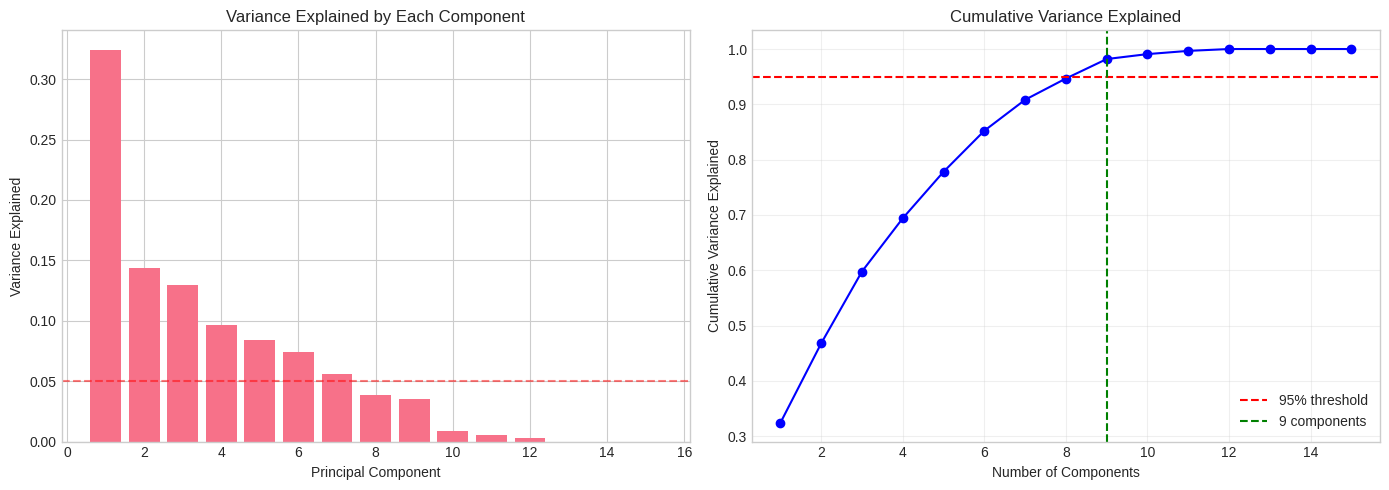

In [6]:
# Visualize variance explained
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance
ax1.bar(range(1, len(pca_full.explained_variance_ratio_)+1),
        pca_full.explained_variance_ratio_)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained')
ax1.set_title('Variance Explained by Each Component')
ax1.axhline(y=0.05, color='r', linestyle='--', alpha=0.5)

# Cumulative variance
ax2.plot(range(1, len(cumsum_variance)+1), cumsum_variance, 'bo-')
ax2.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax2.axvline(x=n_components_95, color='g', linestyle='--', label=f'{n_components_95} components')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance Explained')
ax2.set_title('Cumulative Variance Explained')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Apply PCA with optimal number of components
pca = PCA(n_components=n_components_95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original shape: {X_train_scaled.shape}")
print(f"PCA shape: {X_train_pca.shape}")
print(f"Dimension reduction: {X_train.shape[1]} → {X_train_pca.shape[1]}")

Original shape: (328, 15)
PCA shape: (328, 9)
Dimension reduction: 15 → 9


### Compare Random Forest Performance: Original vs PCA Features

Test if PCA improves the best model from Project 2 (Random Forest with max_depth=20, min_samples_split=2, n_estimators=200)

In [8]:
# Random Forest on original features (scaled)
rf_original = RandomForestClassifier(max_depth=20, min_samples_split=2,
                                     n_estimators=200, random_state=42)
rf_original.fit(X_train_scaled, y_train)

train_acc_orig = rf_original.score(X_train_scaled, y_train)
test_acc_orig = rf_original.score(X_test_scaled, y_test)

print("Random Forest on Original Features (Scaled):")
print(f"  Training accuracy: {train_acc_orig:.4f}")
print(f"  Test accuracy: {test_acc_orig:.4f}")

Random Forest on Original Features (Scaled):
  Training accuracy: 1.0000
  Test accuracy: 0.6463


In [9]:
# Random Forest on PCA features
rf_pca = RandomForestClassifier(max_depth=20, min_samples_split=2,
                               n_estimators=200, random_state=42)
rf_pca.fit(X_train_pca, y_train)

train_acc_pca = rf_pca.score(X_train_pca, y_train)
test_acc_pca = rf_pca.score(X_test_pca, y_test)

print("Random Forest on PCA Features:")
print(f"  Training accuracy: {train_acc_pca:.4f}")
print(f"  Test accuracy: {test_acc_pca:.4f}")

print("\nComparison:")
print(f"  Change in test accuracy: {test_acc_pca - test_acc_orig:+.4f}")
if test_acc_pca > test_acc_orig:
    print("  → PCA improved performance")
elif test_acc_pca < test_acc_orig:
    print("  → Original features performed better")
else:
    print("  → No change in performance")

Random Forest on PCA Features:
  Training accuracy: 1.0000
  Test accuracy: 0.5732

Comparison:
  Change in test accuracy: -0.0732
  → Original features performed better


---

## Step 3: Clustering Analysis

Apply three clustering algorithms both with and without PCA. Evaluate using ARI (Adjusted Rand Index) and Silhouette Coefficient.

**Note:** For unsupervised learning, we work only with the training set. The target labels (Performance) are used only for evaluation metrics.

### 3.1: K-Means Clustering

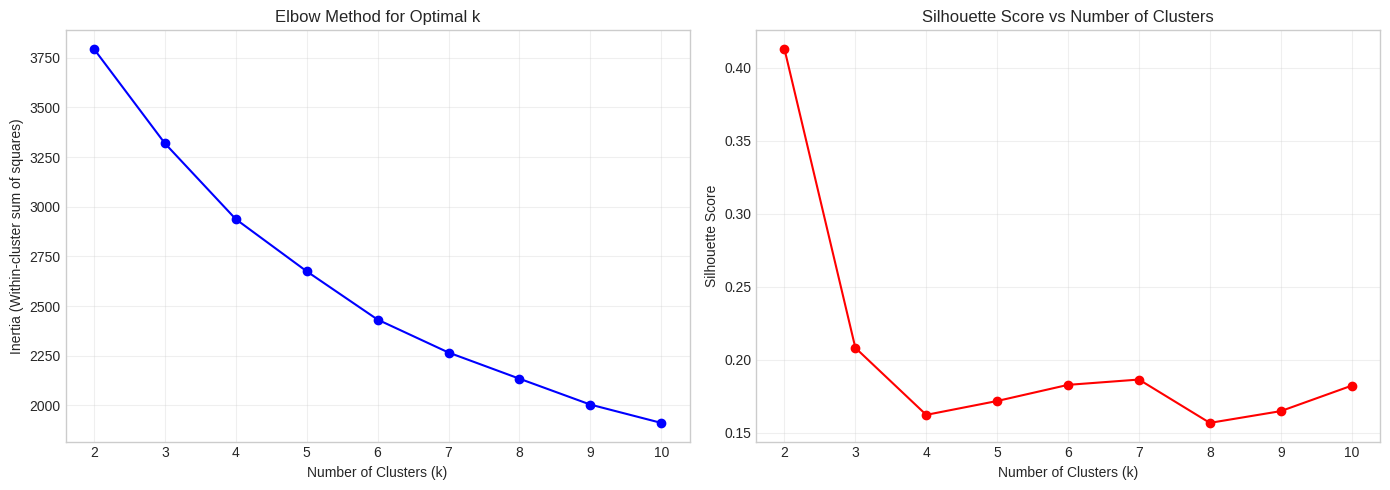


Using k=3 clusters (matches our 3 performance classes)


In [10]:
# Elbow method to find optimal k
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_train_scaled, kmeans.labels_))

# Plot elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Within-cluster sum of squares)')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, silhouettes, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs Number of Clusters')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Select k=3 to match our known classes
optimal_k = 3
print(f"\nUsing k={optimal_k} clusters (matches our 3 performance classes)")

In [11]:
# K-Means on original (scaled) features
kmeans_orig = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_orig = kmeans_orig.fit_predict(X_train_scaled)

# Calculate metrics
ari_orig = adjusted_rand_score(y_train, clusters_orig)
sil_orig = silhouette_score(X_train_scaled, clusters_orig)

print("K-Means on Original Features:")
print(f"  ARI: {ari_orig:.4f}")
print(f"  Silhouette: {sil_orig:.4f}")
print(f"\n  Cluster distribution: {np.bincount(clusters_orig)}")

K-Means on Original Features:
  ARI: 0.0112
  Silhouette: 0.2080

  Cluster distribution: [ 76 224  28]


In [12]:
# K-Means on PCA features
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(X_train_pca)

# Calculate metrics
ari_pca = adjusted_rand_score(y_train, clusters_pca)
sil_pca = silhouette_score(X_train_pca, clusters_pca)

print("K-Means on PCA Features:")
print(f"  ARI: {ari_pca:.4f}")
print(f"  Silhouette: {sil_pca:.4f}")
print(f"\n  Cluster distribution: {np.bincount(clusters_pca)}")

K-Means on PCA Features:
  ARI: 0.0112
  Silhouette: 0.2124

  Cluster distribution: [ 76 224  28]


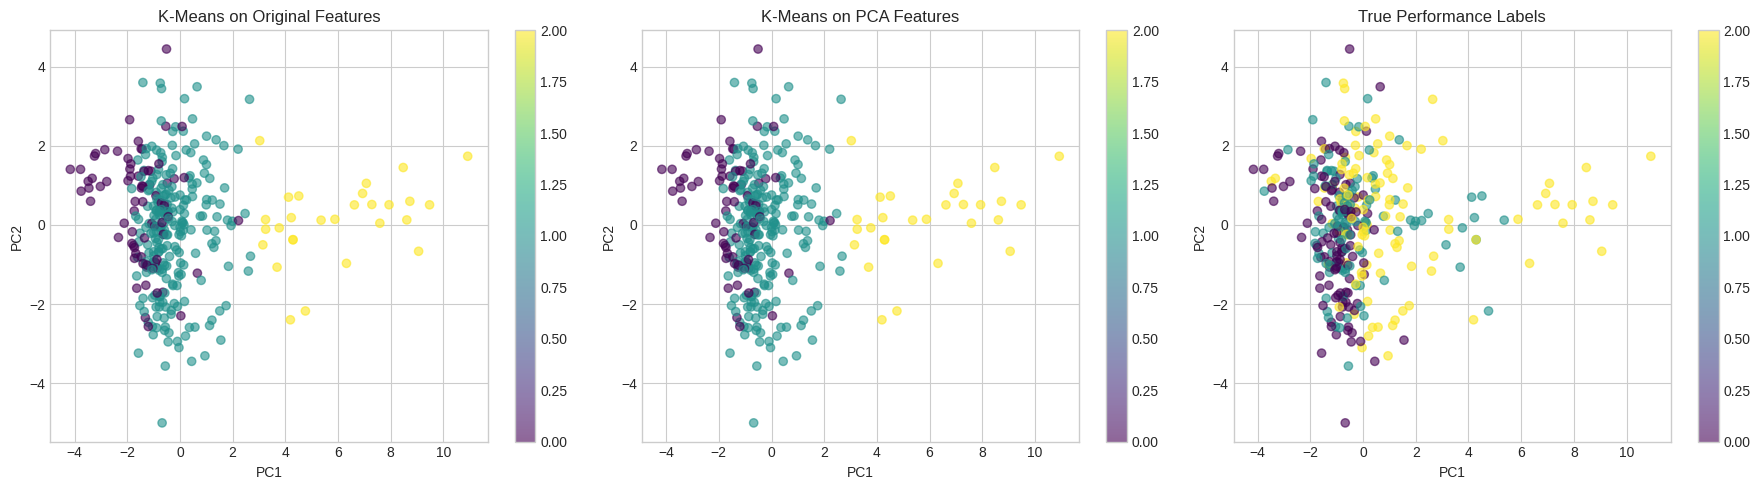

In [13]:
# Visualize K-Means results using first 2 PCs
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_train_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original clusters
scatter1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters_orig, cmap='viridis', alpha=0.6)
axes[0].set_title('K-Means on Original Features')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])

# PCA clusters
scatter2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters_pca, cmap='viridis', alpha=0.6)
axes[1].set_title('K-Means on PCA Features')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1])

# True labels
label_map = {'Low': 0, 'Medium': 1, 'High': 2}
y_numeric = y_train.map(label_map)
scatter3 = axes[2].scatter(X_2d[:, 0], X_2d[:, 1], c=y_numeric, cmap='viridis', alpha=0.6)
axes[2].set_title('True Performance Labels')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
plt.colorbar(scatter3, ax=axes[2])

plt.tight_layout()
plt.show()

### 3.2: Hierarchical (Agglomerative) Clustering

In [14]:
# Hierarchical clustering on original features
agg_orig = AgglomerativeClustering(n_clusters=3, linkage='ward')
clusters_agg_orig = agg_orig.fit_predict(X_train_scaled)

# Calculate metrics
ari_agg_orig = adjusted_rand_score(y_train, clusters_agg_orig)
sil_agg_orig = silhouette_score(X_train_scaled, clusters_agg_orig)

print("Hierarchical Clustering on Original Features:")
print(f"  ARI: {ari_agg_orig:.4f}")
print(f"  Silhouette: {sil_agg_orig:.4f}")
print(f"\n  Cluster distribution: {np.bincount(clusters_agg_orig)}")

Hierarchical Clustering on Original Features:
  ARI: 0.0124
  Silhouette: 0.2008

  Cluster distribution: [221  29  78]


In [15]:
# Hierarchical clustering on PCA features
agg_pca = AgglomerativeClustering(n_clusters=3, linkage='ward')
clusters_agg_pca = agg_pca.fit_predict(X_train_pca)

# Calculate metrics
ari_agg_pca = adjusted_rand_score(y_train, clusters_agg_pca)
sil_agg_pca = silhouette_score(X_train_pca, clusters_agg_pca)

print("Hierarchical Clustering on PCA Features:")
print(f"  ARI: {ari_agg_pca:.4f}")
print(f"  Silhouette: {sil_agg_pca:.4f}")
print(f"\n  Cluster distribution: {np.bincount(clusters_agg_pca)}")

Hierarchical Clustering on PCA Features:
  ARI: 0.0059
  Silhouette: 0.1801

  Cluster distribution: [232  13  83]


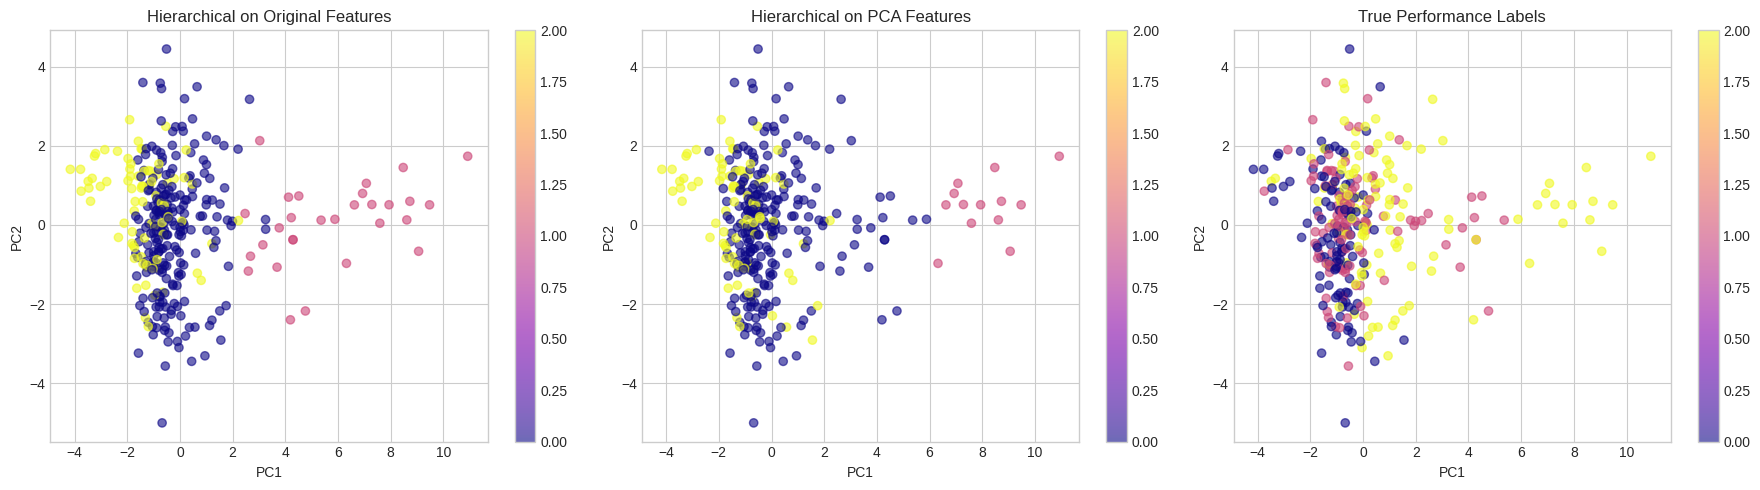

In [16]:
# Visualize Hierarchical clustering results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original clusters
scatter1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters_agg_orig, cmap='plasma', alpha=0.6)
axes[0].set_title('Hierarchical on Original Features')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])

# PCA clusters
scatter2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters_agg_pca, cmap='plasma', alpha=0.6)
axes[1].set_title('Hierarchical on PCA Features')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1])

# True labels
scatter3 = axes[2].scatter(X_2d[:, 0], X_2d[:, 1], c=y_numeric, cmap='plasma', alpha=0.6)
axes[2].set_title('True Performance Labels')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
plt.colorbar(scatter3, ax=axes[2])

plt.tight_layout()
plt.show()

### 3.3: DBSCAN Clustering

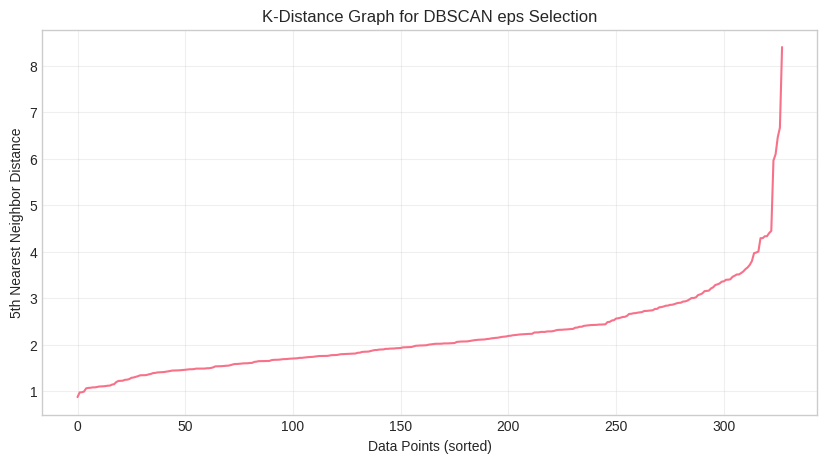

Look for 'elbow' in the plot to choose eps value
Suggested eps range: 3.66 to 4.40


In [17]:
# Test different eps values to find reasonable clustering
from sklearn.neighbors import NearestNeighbors

# Calculate k-nearest neighbors distances to help choose eps
neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_train_scaled)
distances, indices = neighbors.kneighbors(X_train_scaled)

# Sort and plot distances
distances = np.sort(distances[:, -1], axis=0)
plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.xlabel('Data Points (sorted)')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('K-Distance Graph for DBSCAN eps Selection')
plt.grid(True, alpha=0.3)
plt.show()

print("Look for 'elbow' in the plot to choose eps value")
print(f"Suggested eps range: {distances[int(len(distances)*0.95)]:.2f} to {distances[int(len(distances)*0.98)]:.2f}")

In [18]:
# DBSCAN on original features
# Start with eps based on k-distance plot
dbscan_orig = DBSCAN(eps=2.5, min_samples=5)
clusters_db_orig = dbscan_orig.fit_predict(X_train_scaled)

# Calculate metrics (exclude noise points labeled -1)
n_clusters_orig = len(set(clusters_db_orig)) - (1 if -1 in clusters_db_orig else 0)
n_noise_orig = list(clusters_db_orig).count(-1)

print("DBSCAN on Original Features:")
print(f"  Number of clusters: {n_clusters_orig}")
print(f"  Number of noise points: {n_noise_orig}")

if n_clusters_orig > 1 and n_noise_orig < len(clusters_db_orig):
    # Only calculate if we have valid clusters
    mask = clusters_db_orig != -1
    ari_db_orig = adjusted_rand_score(y_train[mask], clusters_db_orig[mask])
    sil_db_orig = silhouette_score(X_train_scaled[mask], clusters_db_orig[mask])
    print(f"  ARI: {ari_db_orig:.4f}")
    print(f"  Silhouette: {sil_db_orig:.4f}")
else:
    print("  ARI: N/A (insufficient clusters)")
    print(f"  Silhouette: N/A (insufficient clusters)")
    ari_db_orig = 0
    sil_db_orig = 0

print(f"\n  Cluster distribution: {np.bincount(clusters_db_orig[clusters_db_orig >= 0])}")

DBSCAN on Original Features:
  Number of clusters: 1
  Number of noise points: 52
  ARI: N/A (insufficient clusters)
  Silhouette: N/A (insufficient clusters)

  Cluster distribution: [276]


In [19]:
# DBSCAN on PCA features
dbscan_pca = DBSCAN(eps=1.5, min_samples=5)
clusters_db_pca = dbscan_pca.fit_predict(X_train_pca)

# Calculate metrics
n_clusters_pca = len(set(clusters_db_pca)) - (1 if -1 in clusters_db_pca else 0)
n_noise_pca = list(clusters_db_pca).count(-1)

print("DBSCAN on PCA Features:")
print(f"  Number of clusters: {n_clusters_pca}")
print(f"  Number of noise points: {n_noise_pca}")

if n_clusters_pca > 1 and n_noise_pca < len(clusters_db_pca):
    mask = clusters_db_pca != -1
    ari_db_pca = adjusted_rand_score(y_train[mask], clusters_db_pca[mask])
    sil_db_pca = silhouette_score(X_train_pca[mask], clusters_db_pca[mask])
    print(f"  ARI: {ari_db_pca:.4f}")
    print(f"  Silhouette: {sil_db_pca:.4f}")
else:
    print("  ARI: N/A (insufficient clusters)")
    print(f"  Silhouette: N/A (insufficient clusters)")
    ari_db_pca = 0
    sil_db_pca = 0

print(f"\n  Cluster distribution: {np.bincount(clusters_db_pca[clusters_db_pca >= 0])}")

DBSCAN on PCA Features:
  Number of clusters: 3
  Number of noise points: 215
  ARI: 0.0014
  Silhouette: 0.2581

  Cluster distribution: [103   5   5]


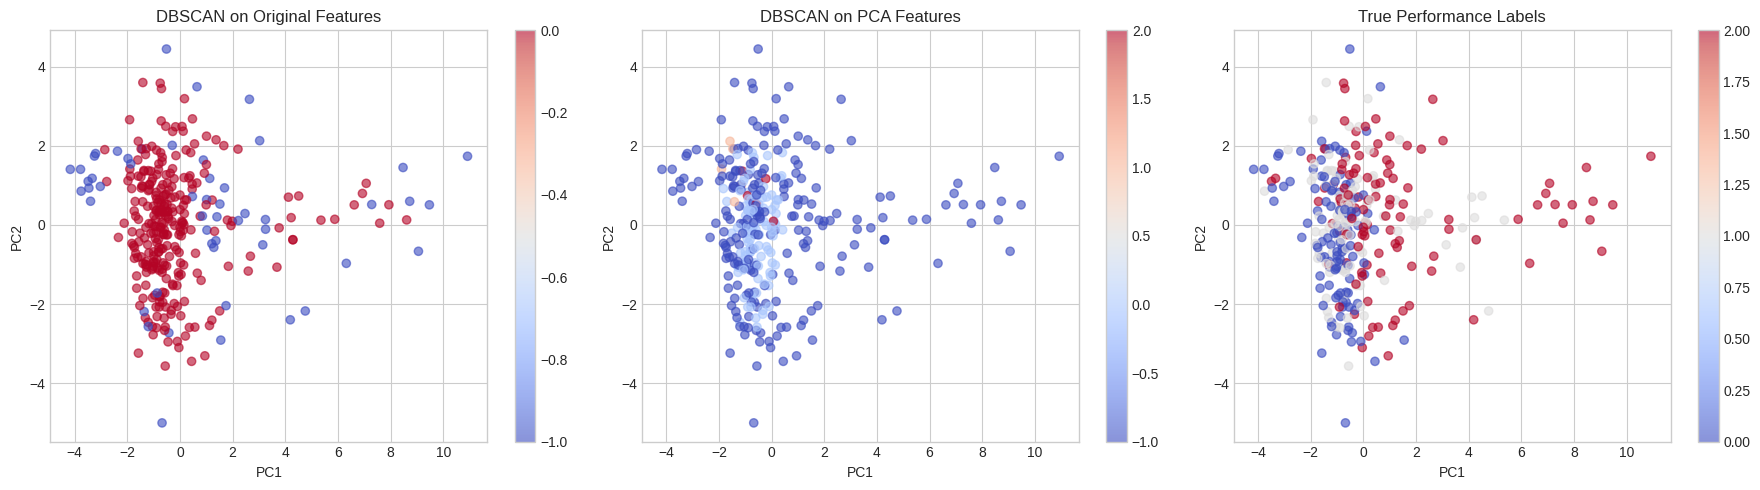

In [20]:
# Visualize DBSCAN results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original clusters
scatter1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters_db_orig, cmap='coolwarm', alpha=0.6)
axes[0].set_title('DBSCAN on Original Features')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])

# PCA clusters
scatter2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters_db_pca, cmap='coolwarm', alpha=0.6)
axes[1].set_title('DBSCAN on PCA Features')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1])

# True labels
scatter3 = axes[2].scatter(X_2d[:, 0], X_2d[:, 1], c=y_numeric, cmap='coolwarm', alpha=0.6)
axes[2].set_title('True Performance Labels')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
plt.colorbar(scatter3, ax=axes[2])

plt.tight_layout()
plt.show()

---

## Step 4: Summary and Comparison

In [21]:
# Create summary table
results = pd.DataFrame({
    'Algorithm': ['K-Means', 'K-Means', 'Hierarchical', 'Hierarchical', 'DBSCAN', 'DBSCAN'],
    'Features': ['Original', 'PCA', 'Original', 'PCA', 'Original', 'PCA'],
    'ARI': [ari_orig, ari_pca, ari_agg_orig, ari_agg_pca, ari_db_orig, ari_db_pca],
    'Silhouette': [sil_orig, sil_pca, sil_agg_orig, sil_agg_pca, sil_db_orig, sil_db_pca]
})

print("\n" + "="*70)
print("CLUSTERING RESULTS SUMMARY")
print("="*70)
print(results.to_string(index=False))
print("="*70)

# Find best performers
best_ari_idx = results['ARI'].idxmax()
best_sil_idx = results['Silhouette'].idxmax()

print(f"\nBest ARI: {results.loc[best_ari_idx, 'Algorithm']} on {results.loc[best_ari_idx, 'Features']} features")
print(f"  Score: {results.loc[best_ari_idx, 'ARI']:.4f}")

print(f"\nBest Silhouette: {results.loc[best_sil_idx, 'Algorithm']} on {results.loc[best_sil_idx, 'Features']} features")
print(f"  Score: {results.loc[best_sil_idx, 'Silhouette']:.4f}")


CLUSTERING RESULTS SUMMARY
   Algorithm Features      ARI  Silhouette
     K-Means Original 0.011215    0.208040
     K-Means      PCA 0.011215    0.212384
Hierarchical Original 0.012366    0.200776
Hierarchical      PCA 0.005875    0.180146
      DBSCAN Original 0.000000    0.000000
      DBSCAN      PCA 0.001442    0.258110

Best ARI: Hierarchical on Original features
  Score: 0.0124

Best Silhouette: DBSCAN on PCA features
  Score: 0.2581


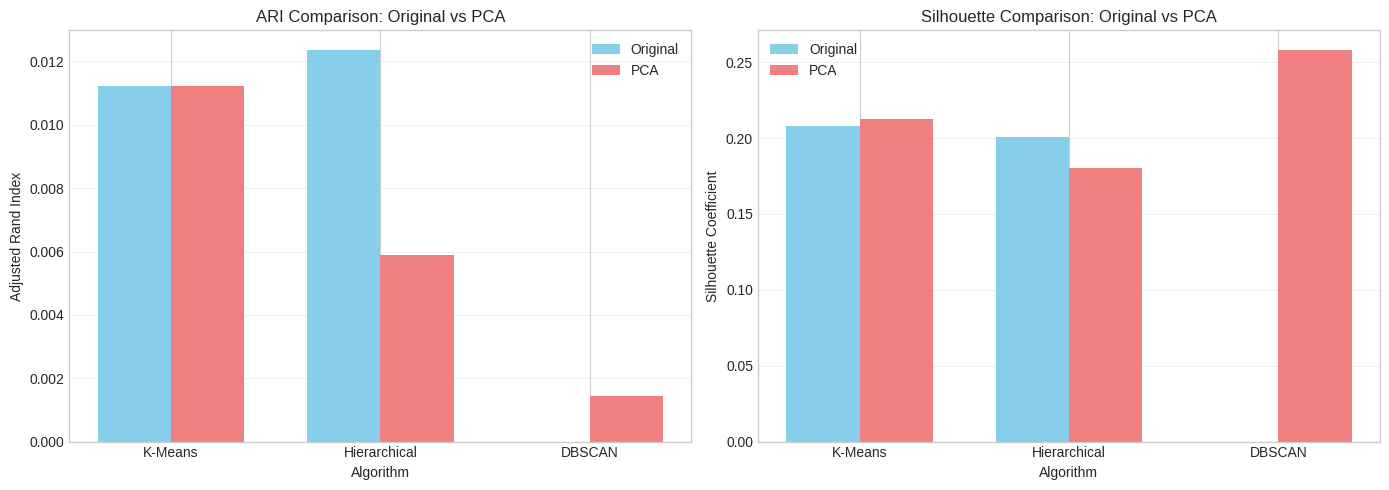

In [22]:
# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ARI comparison
x = np.arange(len(results)//2)
width = 0.35
algorithms = ['K-Means', 'Hierarchical', 'DBSCAN']

ari_orig_vals = results[results['Features']=='Original']['ARI'].values
ari_pca_vals = results[results['Features']=='PCA']['ARI'].values

ax1.bar(x - width/2, ari_orig_vals, width, label='Original', color='skyblue')
ax1.bar(x + width/2, ari_pca_vals, width, label='PCA', color='lightcoral')
ax1.set_xlabel('Algorithm')
ax1.set_ylabel('Adjusted Rand Index')
ax1.set_title('ARI Comparison: Original vs PCA')
ax1.set_xticks(x)
ax1.set_xticklabels(algorithms)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Silhouette comparison
sil_orig_vals = results[results['Features']=='Original']['Silhouette'].values
sil_pca_vals = results[results['Features']=='PCA']['Silhouette'].values

ax2.bar(x - width/2, sil_orig_vals, width, label='Original', color='skyblue')
ax2.bar(x + width/2, sil_pca_vals, width, label='PCA', color='lightcoral')
ax2.set_xlabel('Algorithm')
ax2.set_ylabel('Silhouette Coefficient')
ax2.set_title('Silhouette Comparison: Original vs PCA')
ax2.set_xticks(x)
ax2.set_xticklabels(algorithms)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---

## Results Summary and Analysis

### Key Findings:

**PCA Analysis:**
- Reduced from 15 features to 9 components (98.19% variance retained)
- PC1 captures 32.42% of variance alone
- Random Forest performance: Original features (64.63%) > PCA features (57.32%)
- Conclusion: PCA helps visualization but hurts predictive performance

**Clustering Results:**

| Algorithm | Features | ARI | Silhouette | Notes |
|-----------|----------|-----|------------|-------|
| K-Means | Original | 0.0112 | 0.2080 | Stable, consistent |
| K-Means | PCA | 0.0112 | 0.2124 | Identical assignments |
| Hierarchical | Original | 0.0124 | 0.2008 | Best ARI |
| Hierarchical | PCA | 0.0059 | 0.1801 | - |
| DBSCAN | Original | 0.0000 | 0.0000 | Only 1 cluster found |
| DBSCAN | PCA | 0.0014 | 0.2581 | 65% labeled as noise |

### Why Low ARI Scores Are Expected:

**Low ARI (~0.01) doesn't mean failure - it reveals something important:**
- ARI measures agreement between clusters and performance labels
- Clusters are based on staffing/demographics; labels are based on test scores
- **Finding:** Schools with similar staffing don't necessarily have similar performance
- **Implication:** Performance is driven by unmeasured factors (teaching quality, curriculum, school culture, resources)

This is the **ecological fallacy** - group-level characteristics don't predict group-level outcomes well.

### Unsupervised vs Supervised Learning:

**Different questions, different answers:**
- **Clustering (Project 3):** "Which schools look similar?" → Natural groupings based on composition
- **Classification (Project 2):** "Which schools will perform well?" → Prediction based on features

**Comparison:**
- Random Forest (Project 2): 64-67% accuracy - decent prediction despite complexity
- Clustering (Project 3): ARI ~0.01 - groupings don't match performance labels
- Both results suggest performance influenced heavily by factors NOT in our dataset

### Algorithm Performance:

**What Worked:**
- K-Means: Fast, stable, reproducible. Same clusters on original and PCA features.
- Hierarchical: Comparable to K-Means. Ward linkage worked well.
- Elbow method clearly indicated k=3 clusters.

**What Didn't Work:**
- DBSCAN: Too sensitive to eps parameter. On original features: only 1 cluster. On PCA: 65% noise points.
- PCA for prediction: Hurt Random Forest accuracy by 7.31%.

**Best Choice:** K-Means for its simplicity and stability.

### Why This Dataset Is Poorly Suited for Clustering:

1. **Continuous outcomes:** Performance exists on a continuum, not discrete groups
2. **Multifactorial:** Test scores influenced by hundreds of unmeasured variables
3. **Limited features:** Only 15 administrative variables (staffing counts, demographics)
4. **Missing key factors:** Teacher quality, curriculum, leadership, resources, peer effects
5. **External influences:** Neighborhood effects, family backgrounds, funding disparities

**Real-world interpretation:** You can't identify "types" of schools by performance using only basic demographic and staffing data.

### Practical Insights:

**For prediction:** Use supervised learning (Random Forest from Project 2)
- 64-67% accuracy shows some predictive power
- Still limited by unmeasured factors

**For exploration:** K-Means can identify schools with similar characteristics
- Useful for finding peer comparison groups
- Don't expect these groups to align with performance

**PCA trade-off:** Good for visualization, bad for prediction
- Use for exploring data structure
- Keep original features for modeling

### Future Directions:

**To improve analysis:**
- Add features: per-pupil spending, teacher qualifications, curriculum type
- Use continuous performance metrics instead of forced Low/Medium/High categories
- Try regression instead of classification
- Cluster by other criteria (resource patterns, school type) not performance

**Key takeaway:** This dataset shows that staffing patterns and demographics alone don't determine school performance - quality factors matter more than quantity factors.